In [20]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DATA_PATH = Path("combined_apr_sep_2025_area1_with_saturated.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {DATA_PATH.resolve()}")

pd.options.display.float_format = "{:,.3f}".format

In [21]:
# Cell 2 — Load and filter unsaturated rows
raw_df = pd.read_csv(DATA_PATH)
raw_df["time"] = pd.to_datetime(raw_df["time"])

initial_rows = len(raw_df)
filtered_df = raw_df.loc[raw_df["saturated"] == 0].copy()
removed_rows = initial_rows - len(filtered_df)

print(f"Initial rows: {initial_rows:,}")
print(f"Rows kept (saturated == 0): {len(filtered_df):,}")
print(f"Rows removed (saturated == 1): {removed_rows:,}")
print(f"Time range after filter: {filtered_df['time'].min()} -> {filtered_df['time'].max()}")

# Remove EUs with known data issues or excluded treatment groups
# - eu_7: sensor error
# - eu_13, eu_21: Polli-mix-2 removed from study per request
excluded_eus = {"eu_7", "eu_13", "eu_21"}
eu_columns = [f"eu_{i}" for i in range(1, 25) if f"eu_{i}" not in excluded_eus]
missing_eu = [c for c in eu_columns if c not in filtered_df.columns]
if missing_eu:
    raise ValueError(f"Missing expected EU columns: {missing_eu}")

# Remove timestamps where any included EU has zero/no production.
# This keeps comparisons aligned on timestamps where all EUs are active.
rows_before_zero_filter = len(filtered_df)
filtered_df = filtered_df.loc[(filtered_df[eu_columns] > 0).all(axis=1)].copy()
rows_removed_zero_filter = rows_before_zero_filter - len(filtered_df)

print(f"Rows removed (any EU <= 0): {rows_removed_zero_filter:,}")
print(f"Rows after zero-value timestamp filter: {len(filtered_df):,}")

Initial rows: 37,728
Rows kept (saturated == 0): 30,170
Rows removed (saturated == 1): 7,558
Time range after filter: 2025-04-18 00:00:00 -> 2025-09-07 23:55:00


In [22]:
# Cell 3 — Reshape to long format, map crops, and remove zero-power rows
crop_to_eus = {
    "Strawberry": ["eu_1", "eu_11", "eu_24"],
    "Squash": ["eu_6", "eu_10", "eu_18"],
    "Broccoli": ["eu_2", "eu_9", "eu_22"],
    "Polli-mix-1": ["eu_4", "eu_12", "eu_23"],
    "Raspberry": ["eu_8", "eu_16", "eu_20"],
    "Pepper": ["eu_3", "eu_14", "eu_19"],
    "Grass": ["eu_5", "eu_15", "eu_17"],
}

crop_order = [
    "Strawberry", "Squash", "Broccoli", "Polli-mix-1",
    "Raspberry", "Pepper", "Grass"
]

# Reverse mapping eu -> crop
eu_to_crop = {
    eu: crop
    for crop, eu_list in crop_to_eus.items()
    for eu in eu_list
}

tidy_df = filtered_df.melt(
    id_vars=["time", "saturated"],
    value_vars=eu_columns,
    var_name="eu_id",
    value_name="power",
)

tidy_df["crop"] = tidy_df["eu_id"].map(eu_to_crop)

if tidy_df["crop"].isna().any():
    missing_map = tidy_df.loc[tidy_df["crop"].isna(), "eu_id"].unique()
    raise ValueError(f"EU values missing crop mapping: {missing_map}")

# Remove night/offline rows with zero output
tidy_df = tidy_df.loc[tidy_df["power"] > 0].copy()

tidy_df["date"] = tidy_df["time"].dt.date
tidy_df["hour"] = tidy_df["time"].dt.hour
tidy_df["month"] = tidy_df["time"].dt.to_period("M").astype(str)
tidy_df["crop"] = pd.Categorical(tidy_df["crop"], categories=crop_order, ordered=True)

print(f"Tidy rows (power > 0): {len(tidy_df):,}")
print("Rows per crop:\n", tidy_df["crop"].value_counts().reindex(crop_order))
tidy_df.head()

Tidy rows (power > 0): 255,671
Rows per crop:
 crop
Strawberry     40395
Squash         34808
Broccoli       32960
Polli-mix-1    40009
Raspberry      41614
Pepper         33176
Grass          32709
Name: count, dtype: int64


,time,saturated,eu_id,power,crop,date,hour,month
87,2025-04-18 07:15:00,0,eu_1,16.925,Strawberry,2025-04-18,7,2025-04
88,2025-04-18 07:20:00,0,eu_1,104.967,Strawberry,2025-04-18,7,2025-04
89,2025-04-18 07:25:00,0,eu_1,140.747,Strawberry,2025-04-18,7,2025-04
90,2025-04-18 07:30:00,0,eu_1,63.758,Strawberry,2025-04-18,7,2025-04
91,2025-04-18 07:35:00,0,eu_1,96.587,Strawberry,2025-04-18,7,2025-04


Descriptive statistics by crop (unsaturated, power > 0):


,count,mean,median,std,min,max
crop,,,,,,
Strawberry,40395,"2,599.715","2,126.046","2,105.588",0.527,"8,903.645"
Squash,34808,"2,525.746","2,017.905","2,107.567",2.389,"9,033.329"
Broccoli,32960,"2,560.617","2,049.753","2,094.018",0.529,"8,970.691"
Polli-mix-1,40009,"2,615.640","2,140.653","2,112.141",2.123,"9,175.502"
Raspberry,41614,"2,556.529","2,067.099","2,102.170",2.141,"9,026.370"
Pepper,33176,"2,580.166","2,094.365","2,101.405",5.344,"8,959.418"
Grass,32709,"2,573.314","2,097.614","2,081.083",0.534,"8,941.453"


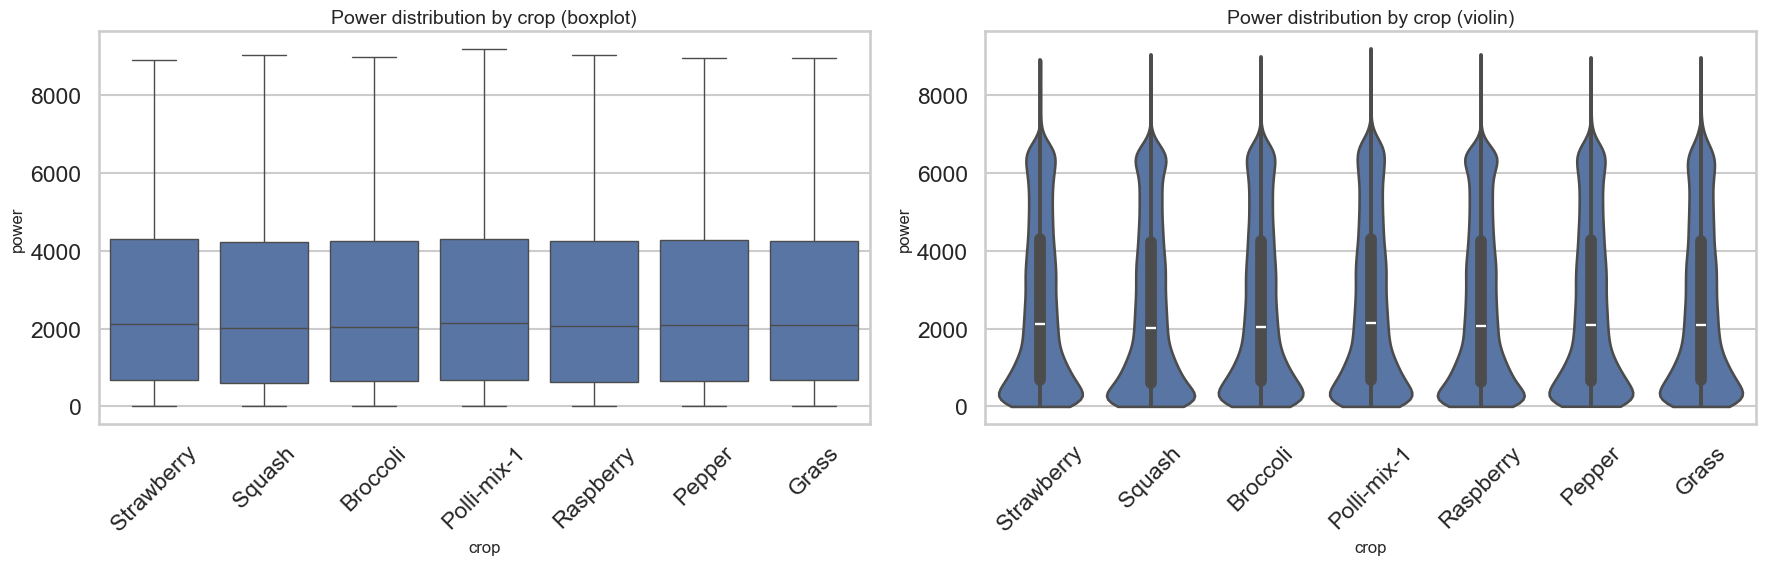

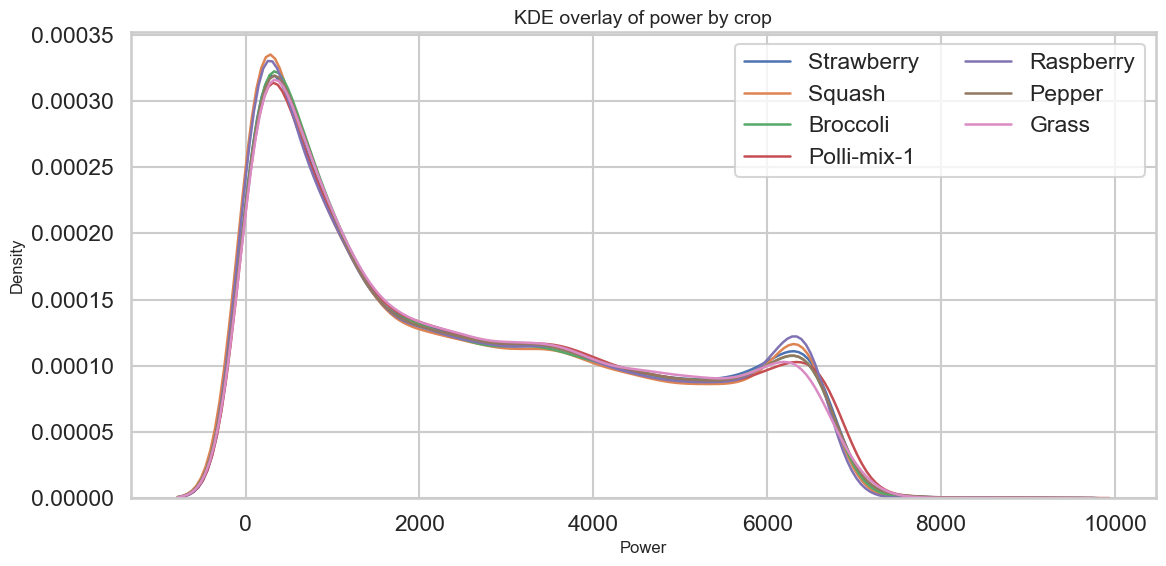

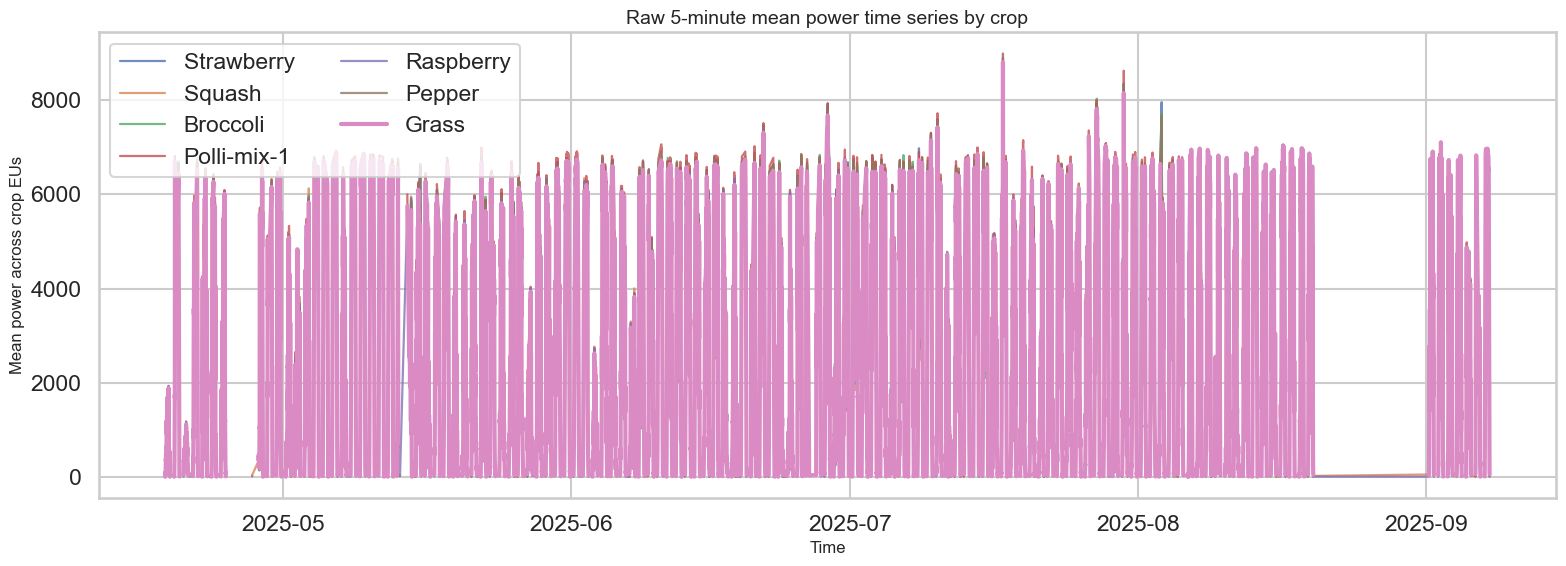

In [23]:
# Cell 4 — Exploratory Data Analysis
eda_stats = (
    tidy_df.groupby("crop", observed=False)["power"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(crop_order)
)
print("Descriptive statistics by crop (unsaturated, power > 0):")
display(eda_stats)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=tidy_df, x="crop", y="power", order=crop_order, ax=axes[0])
axes[0].set_title("Power distribution by crop (boxplot)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=tidy_df, x="crop", y="power", order=crop_order, cut=0, ax=axes[1])
axes[1].set_title("Power distribution by crop (violin)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for crop in crop_order:
    series = tidy_df.loc[tidy_df["crop"] == crop, "power"]
    sns.kdeplot(series, label=crop, linewidth=1.8)
plt.title("KDE overlay of power by crop")
plt.xlabel("Power")
plt.ylabel("Density")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

raw_ts = (
    tidy_df.groupby(["time", "crop"], observed=False)["power"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))
for crop in crop_order:
    sub = raw_ts.loc[raw_ts["crop"] == crop]
    lw = 3 if crop == "Grass" else 1.6
    alpha = 1.0 if crop == "Grass" else 0.8
    plt.plot(sub["time"], sub["power"], label=crop, linewidth=lw, alpha=alpha)
plt.title("Raw 5-minute mean power time series by crop")
plt.xlabel("Time")
plt.ylabel("Mean power across crop EUs")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Daily aggregated rows: 18,963
Daily range: 2025-04-18 -> 2025-09-07


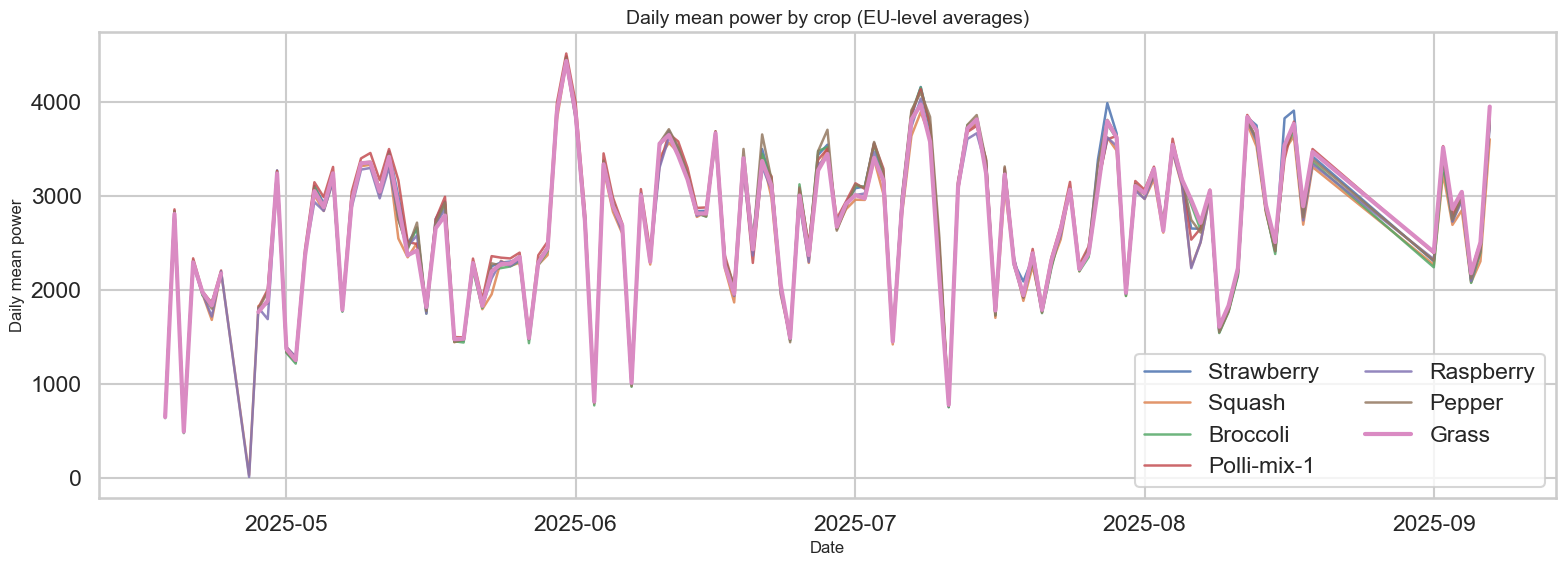

In [24]:
# Cell 5 — Daily aggregation for time-series-safe inference
daily_df = (
    tidy_df.groupby(["date", "eu_id", "crop"], observed=False)["power"]
    .mean()
    .reset_index(name="daily_mean_power")
)
daily_df["date"] = pd.to_datetime(daily_df["date"])

print(f"Daily aggregated rows: {len(daily_df):,}")
print(f"Daily range: {daily_df['date'].min().date()} -> {daily_df['date'].max().date()}")

daily_crop_mean = (
    daily_df.groupby(["date", "crop"], observed=False)["daily_mean_power"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))
for crop in crop_order:
    sub = daily_crop_mean.loc[daily_crop_mean["crop"] == crop]
    lw = 3 if crop == "Grass" else 1.8
    alpha = 1.0 if crop == "Grass" else 0.85
    plt.plot(sub["date"], sub["daily_mean_power"], label=crop, linewidth=lw, alpha=alpha)
plt.title("Daily mean power by crop (EU-level averages)")
plt.xlabel("Date")
plt.ylabel("Daily mean power")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Residual Shapiro-Wilk p-value: 0.0
Group-level Shapiro p-values:


,shapiro_p
Strawberry,NaN
Squash,NaN
Broccoli,NaN
Polli-mix-1,NaN
Raspberry,NaN
Pepper,NaN
Grass,NaN


Normality violated: using Kruskal-Wallis test as primary omnibus test.
Kruskal-Wallis H-statistic: nan
Kruskal-Wallis p-value: nan
Tukey HSD pairwise comparisons:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Broccoli,Grass,NaN,NaN,NaN,NaN,False
1,Broccoli,Pepper,NaN,NaN,NaN,NaN,False
2,Broccoli,Polli-mix-1,NaN,NaN,NaN,NaN,False
3,Broccoli,Raspberry,NaN,NaN,NaN,NaN,False
4,Broccoli,Squash,NaN,NaN,NaN,NaN,False
5,Broccoli,Strawberry,NaN,NaN,NaN,NaN,False
6,Grass,Pepper,NaN,NaN,NaN,NaN,False
7,Grass,Polli-mix-1,NaN,NaN,NaN,NaN,False
8,Grass,Raspberry,NaN,NaN,NaN,NaN,False
9,Grass,Squash,NaN,NaN,NaN,NaN,False


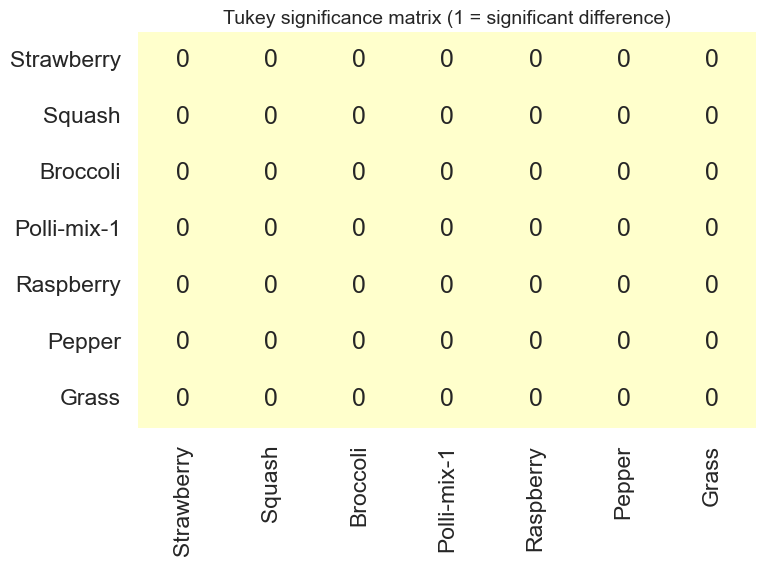

Effect sizes (Cohen's d) vs Grass:


,cohens_d_vs_grass
Strawberry,NaN
Squash,NaN
Broccoli,NaN
Polli-mix-1,NaN
Raspberry,NaN
Pepper,NaN
Grass,NaN


Within-crop variability (coefficient of variation):


,mean,std,cv
crop,,,
Strawberry,"2,713.677",807.217,0.297
Squash,"2,610.993",795.189,0.305
Broccoli,"2,678.324",807.491,0.301
Polli-mix-1,"2,736.670",798.594,0.292
Raspberry,"2,650.981",780.746,0.295
Pepper,"2,697.524",809.423,0.300
Grass,"2,684.176",788.897,0.294


In [25]:
# Cell 6 — Statistical significance testing

def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled

# OLS model for ANOVA and residual checks
ols_model = smf.ols("daily_mean_power ~ C(crop)", data=daily_df).fit()
residuals = ols_model.resid

# Normality checks
group_shapiro = {}
for crop in crop_order:
    group_vals = daily_df.loc[daily_df["crop"] == crop, "daily_mean_power"]
    sample_for_test = group_vals.sample(min(len(group_vals), 500), random_state=42)
    if len(sample_for_test) >= 3:
        group_shapiro[crop] = stats.shapiro(sample_for_test).pvalue
    else:
        group_shapiro[crop] = np.nan

global_shapiro_p = stats.shapiro(residuals.sample(min(len(residuals), 5000), random_state=42)).pvalue
normality_ok = (global_shapiro_p > 0.05) and all((p > 0.05) or np.isnan(p) for p in group_shapiro.values())

print("Residual Shapiro-Wilk p-value:", round(global_shapiro_p, 6))
print("Group-level Shapiro p-values:")
display(pd.Series(group_shapiro).reindex(crop_order).to_frame("shapiro_p"))

if normality_ok:
    print("Using one-way ANOVA (normality assumptions approximately satisfied).")
    anova_table = sm.stats.anova_lm(ols_model, typ=2)
    f_stat = anova_table.loc["C(crop)", "F"]
    p_val = anova_table.loc["C(crop)", "PR(>F)"]

    ss_between = anova_table.loc["C(crop)", "sum_sq"]
    ss_within = anova_table.loc["Residual", "sum_sq"]
    eta_sq = ss_between / (ss_between + ss_within)

    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_val:.6g}")
    print(f"Eta-squared (eta^2): {eta_sq:.4f}")
else:
    print("Normality violated: using Kruskal-Wallis test as primary omnibus test.")
    grouped = [
        daily_df.loc[daily_df["crop"] == crop, "daily_mean_power"].values
        for crop in crop_order
    ]
    kw_stat, kw_p = stats.kruskal(*grouped)
    print(f"Kruskal-Wallis H-statistic: {kw_stat:.4f}")
    print(f"Kruskal-Wallis p-value: {kw_p:.6g}")

# Tukey HSD post-hoc comparisons (useful for pairwise interpretation)
tukey = pairwise_tukeyhsd(
    endog=daily_df["daily_mean_power"],
    groups=daily_df["crop"],
    alpha=0.05,
)
tukey_df = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
print("Tukey HSD pairwise comparisons:")
display(tukey_df)

# Significance matrix heatmap from Tukey results
sig_matrix = pd.DataFrame(False, index=crop_order, columns=crop_order)
for _, row in tukey_df.iterrows():
    g1, g2, reject = row["group1"], row["group2"], bool(row["reject"])
    sig_matrix.loc[g1, g2] = reject
    sig_matrix.loc[g2, g1] = reject

plt.figure(figsize=(8, 6))
sns.heatmap(sig_matrix.astype(int), annot=True, fmt="d", cmap="YlOrRd", cbar=False)
plt.title("Tukey significance matrix (1 = significant difference)")
plt.tight_layout()
plt.show()

# Effect sizes (Cohen's d) vs Grass
grass_vals = daily_df.loc[daily_df["crop"] == "Grass", "daily_mean_power"]
cohens_d_vs_grass = {}
for crop in crop_order:
    crop_vals = daily_df.loc[daily_df["crop"] == crop, "daily_mean_power"]
    cohens_d_vs_grass[crop] = cohens_d(crop_vals, grass_vals)

effect_df = pd.DataFrame({
    "cohens_d_vs_grass": pd.Series(cohens_d_vs_grass),
}).reindex(crop_order)
print("Effect sizes (Cohen's d) vs Grass:")
display(effect_df)

# Within-crop variability (CV)
cv_df = (
    daily_df.groupby("crop", observed=False)["daily_mean_power"]
    .agg(mean="mean", std="std")
    .assign(cv=lambda d: d["std"] / d["mean"])
    .reindex(crop_order)
)
print("Within-crop variability (coefficient of variation):")
display(cv_df)

# Save key artifacts for summary cell
stats_artifacts = {
    "normality_ok": normality_ok,
    "global_shapiro_p": global_shapiro_p,
    "tukey_df": tukey_df,
    "effect_df": effect_df,
    "cv_df": cv_df,
}
if normality_ok:
    stats_artifacts["anova_f"] = f_stat
    stats_artifacts["anova_p"] = p_val
    stats_artifacts["eta_sq"] = eta_sq
else:
    stats_artifacts["kruskal_h"] = kw_stat
    stats_artifacts["kruskal_p"] = kw_p

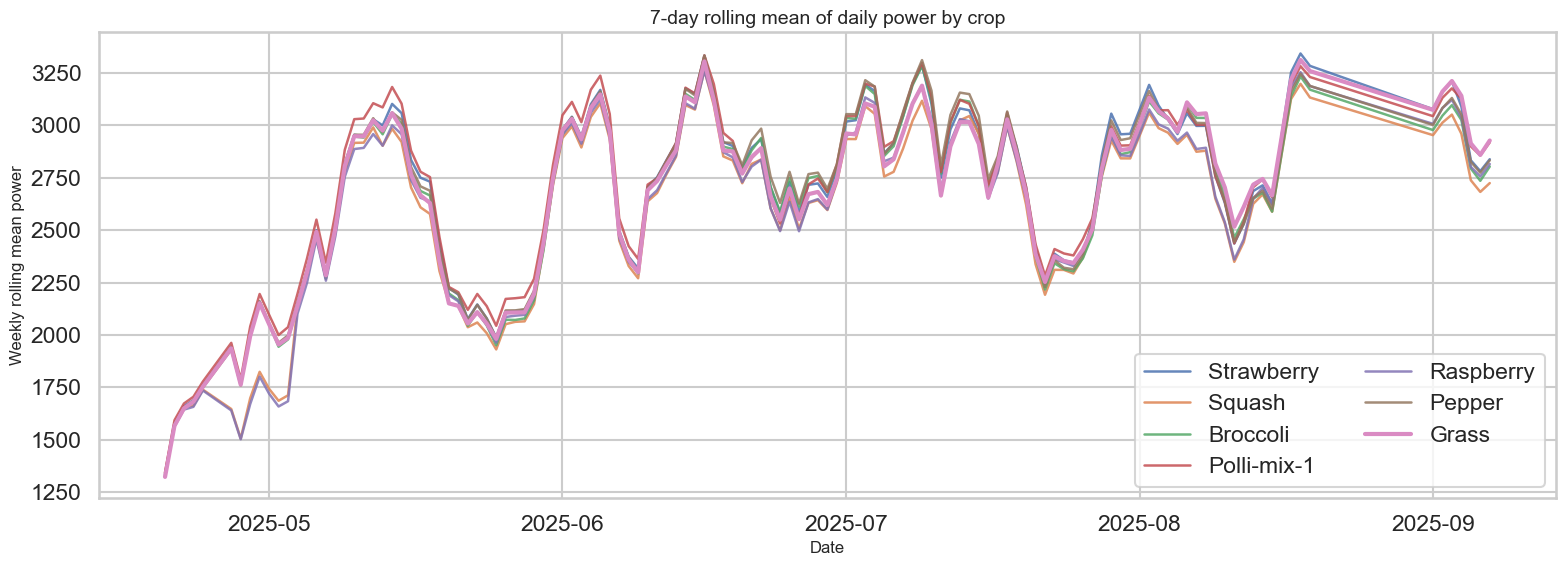

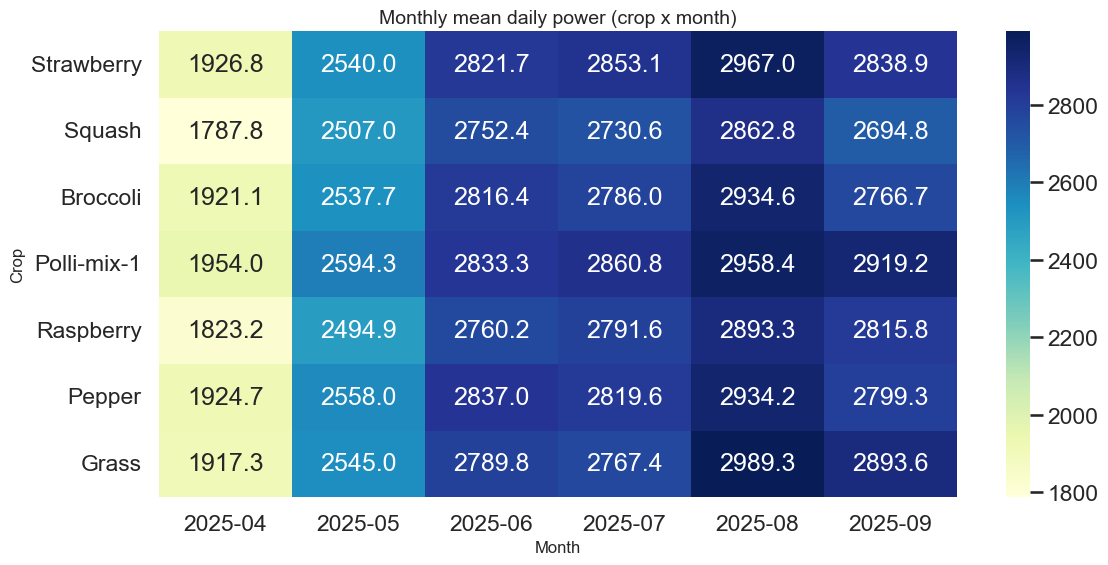

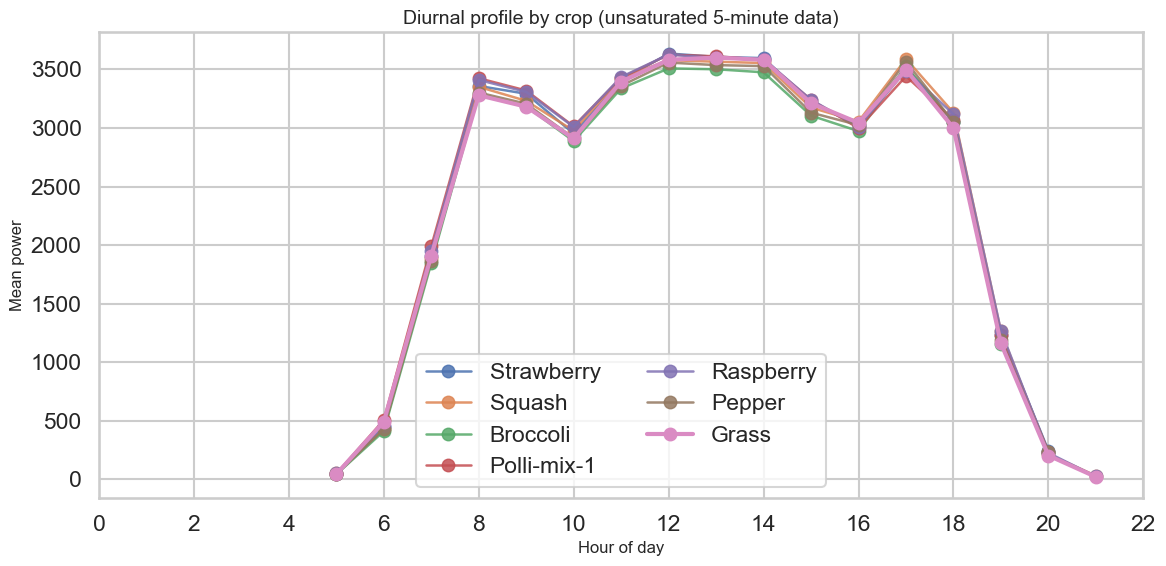

In [26]:
# Cell 7 — Temporal patterns
# Rolling weekly average (7-day) of crop daily means
weekly_df = daily_crop_mean.sort_values(["crop", "date"]).copy()
weekly_df["weekly_roll_mean"] = (
    weekly_df.groupby("crop", observed=False)["daily_mean_power"]
    .transform(lambda s: s.rolling(window=7, min_periods=3).mean())
)

plt.figure(figsize=(16, 6))
for crop in crop_order:
    sub = weekly_df.loc[weekly_df["crop"] == crop]
    lw = 3 if crop == "Grass" else 1.8
    alpha = 1.0 if crop == "Grass" else 0.85
    plt.plot(sub["date"], sub["weekly_roll_mean"], label=crop, linewidth=lw, alpha=alpha)
plt.title("7-day rolling mean of daily power by crop")
plt.xlabel("Date")
plt.ylabel("Weekly rolling mean power")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Monthly heatmap (crop x month)
monthly_heatmap = (
    daily_df.assign(month=daily_df["date"].dt.to_period("M").astype(str))
    .groupby(["crop", "month"], observed=False)["daily_mean_power"]
    .mean()
    .reset_index()
    .pivot(index="crop", columns="month", values="daily_mean_power")
    .reindex(crop_order)
)

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Monthly mean daily power (crop x month)")
plt.xlabel("Month")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

# Diurnal profile from unsaturated 5-minute data
diurnal_df = (
    tidy_df.groupby(["hour", "crop"], observed=False)["power"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for crop in crop_order:
    sub = diurnal_df.loc[diurnal_df["crop"] == crop]
    lw = 3 if crop == "Grass" else 1.8
    alpha = 1.0 if crop == "Grass" else 0.85
    plt.plot(sub["hour"], sub["power"], marker="o", label=crop, linewidth=lw, alpha=alpha)
plt.title("Diurnal profile by crop (unsaturated 5-minute data)")
plt.xlabel("Hour of day")
plt.ylabel("Mean power")
plt.xticks(range(0, 24, 2))
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

,mean_impact_pct,std,n,se,ci95
crop,,,,,
Polli-mix-1,1.647,3.023,128,0.267,0.524
Strawberry,0.535,2.842,128,0.251,0.492
Pepper,0.490,3.421,128,0.302,0.593
Broccoli,-0.332,2.842,128,0.251,0.492
Raspberry,-1.116,3.363,128,0.297,0.583
Squash,-1.855,3.778,128,0.334,0.654


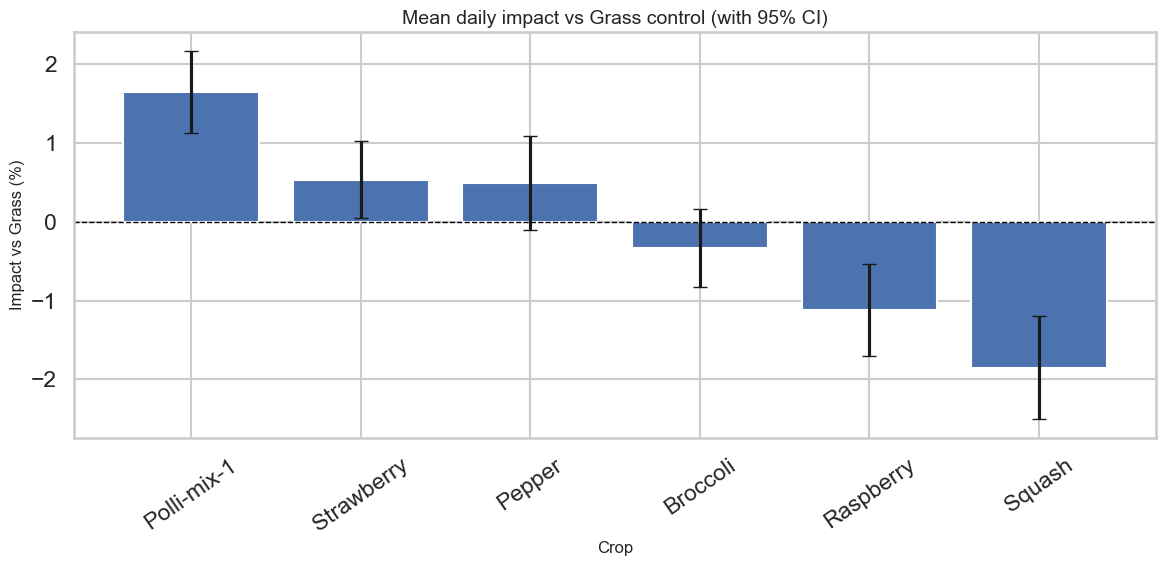

In [27]:
# Cell 8 — Relative impact vs Grass control (daily)
per_day_crop = (
    daily_df.groupby(["date", "crop"], observed=False)["daily_mean_power"]
    .mean()
    .reset_index(name="crop_daily_mean")
)

grass_daily = (
    per_day_crop.loc[per_day_crop["crop"] == "Grass", ["date", "crop_daily_mean"]]
    .rename(columns={"crop_daily_mean": "grass_daily_mean"})
)

impact_df = per_day_crop.merge(grass_daily, on="date", how="inner")
impact_df = impact_df.loc[impact_df["crop"] != "Grass"].copy()
impact_df["daily_impact_pct"] = (
    (impact_df["crop_daily_mean"] - impact_df["grass_daily_mean"])
    / impact_df["grass_daily_mean"]
) * 100

impact_summary = (
    impact_df.groupby("crop", observed=False)["daily_impact_pct"]
    .agg(mean_impact_pct="mean", std="std", n="count")
    .assign(
        se=lambda d: d["std"] / np.sqrt(d["n"]),
        ci95=lambda d: 1.96 * d["se"],
    )
    .reindex([c for c in crop_order if c != "Grass"])
    .sort_values("mean_impact_pct", ascending=False)
)

display(impact_summary)

plt.figure(figsize=(12, 6))
plt.bar(
    impact_summary.index,
    impact_summary["mean_impact_pct"],
    yerr=impact_summary["ci95"],
    capsize=5,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Mean daily impact vs Grass control (with 95% CI)")
plt.ylabel("Impact vs Grass (%)")
plt.xlabel("Crop")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

Pairwise replicate correlations within each crop:


,crop,eu_pair,pearson_r
420,Broccoli,eu_1 vs eu_10,NaN
421,Broccoli,eu_1 vs eu_11,NaN
422,Broccoli,eu_1 vs eu_12,NaN
423,Broccoli,eu_1 vs eu_14,NaN
424,Broccoli,eu_1 vs eu_15,NaN
...,...,...,...
205,Strawberry,eu_5 vs eu_8,NaN
206,Strawberry,eu_5 vs eu_9,NaN
207,Strawberry,eu_6 vs eu_8,NaN
208,Strawberry,eu_6 vs eu_9,NaN


Replicate outlier check (|z| > 2):


,crop,eu_id,mean_daily_power,z_score_within_crop,is_outlier_abs_z_gt_2
42,Broccoli,eu_1,NaN,NaN,False
43,Broccoli,eu_10,NaN,NaN,False
44,Broccoli,eu_11,NaN,NaN,False
45,Broccoli,eu_12,NaN,NaN,False
46,Broccoli,eu_14,NaN,NaN,False
...,...,...,...,...,...
16,Strawberry,eu_4,NaN,NaN,False
17,Strawberry,eu_5,NaN,NaN,False
18,Strawberry,eu_6,NaN,NaN,False
19,Strawberry,eu_8,NaN,NaN,False


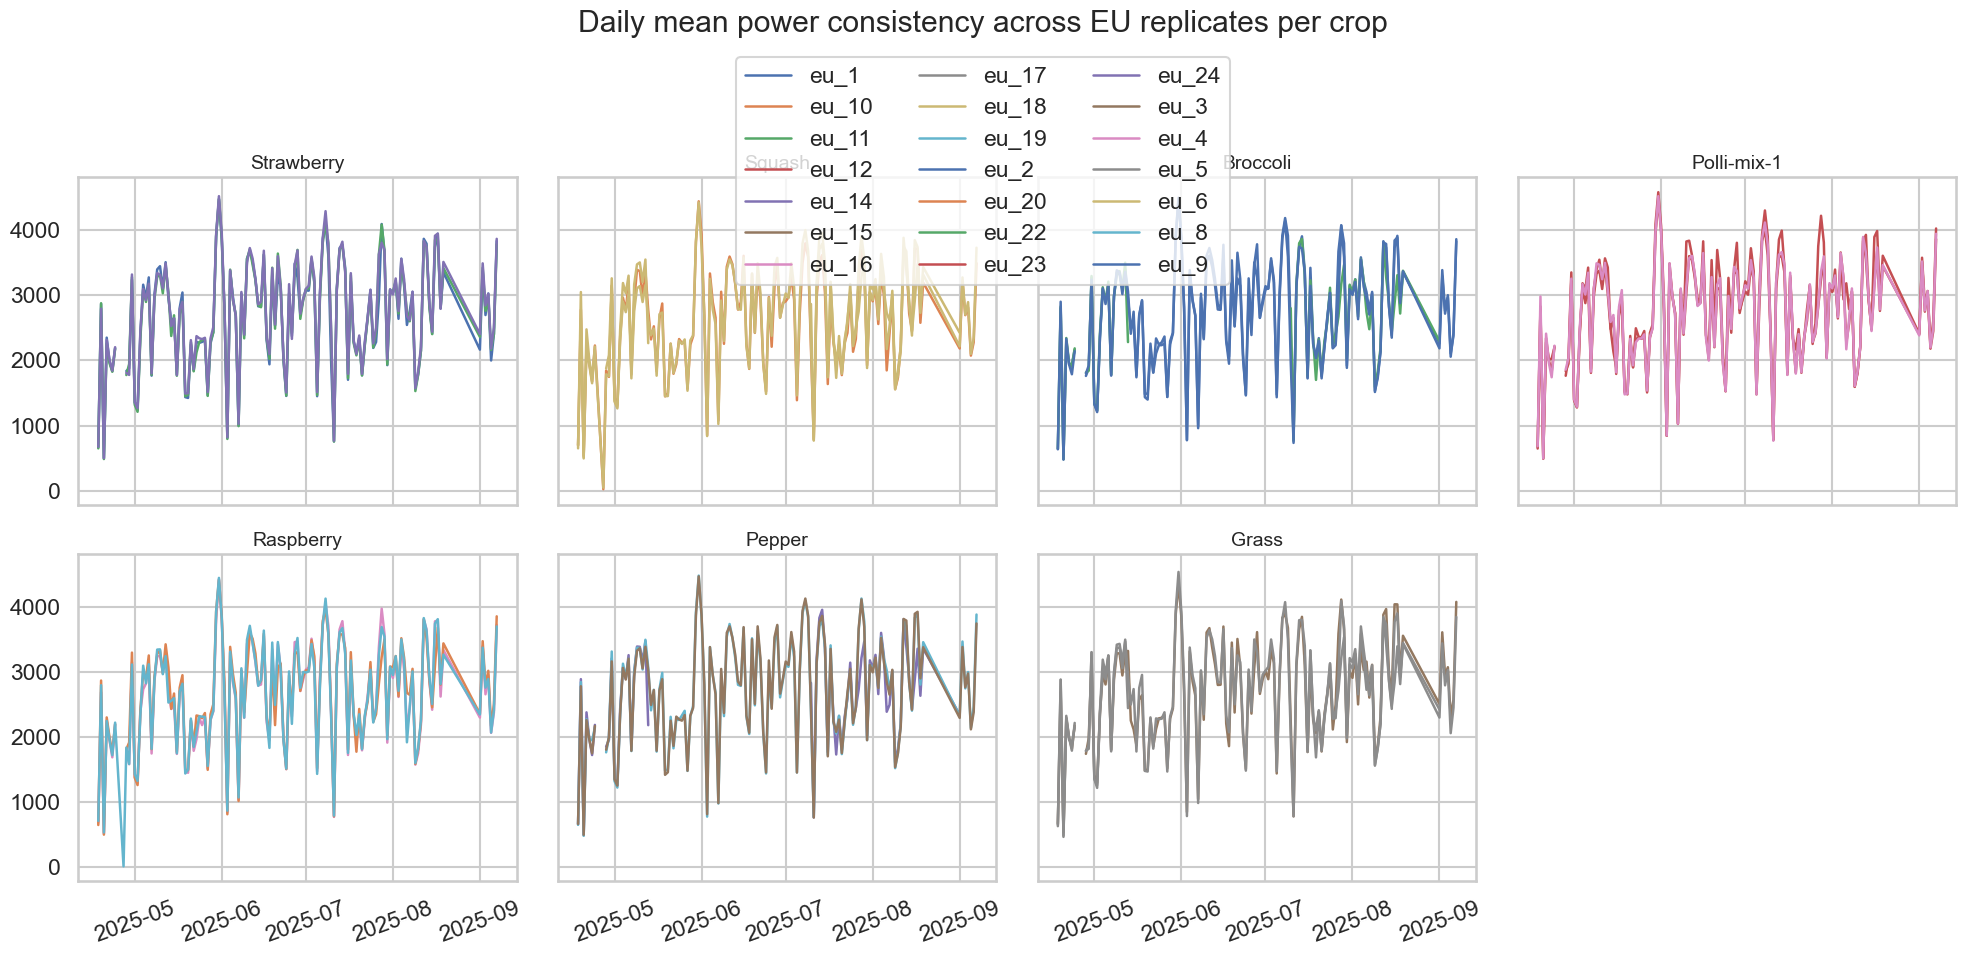

In [28]:
# Cell 9 — Within-crop replicate consistency

eu_daily = (
    daily_df.groupby(["date", "crop", "eu_id"], observed=False)["daily_mean_power"]
    .mean()
    .reset_index()
)

# Pairwise correlations within each crop
corr_rows = []
outlier_rows = []
for crop, grp in eu_daily.groupby("crop", observed=False):
    pivot = grp.pivot(index="date", columns="eu_id", values="daily_mean_power").sort_index()
    corr = pivot.corr()

    eu_ids = list(pivot.columns)
    for i in range(len(eu_ids)):
        for j in range(i + 1, len(eu_ids)):
            corr_rows.append({
                "crop": crop,
                "eu_pair": f"{eu_ids[i]} vs {eu_ids[j]}",
                "pearson_r": corr.loc[eu_ids[i], eu_ids[j]],
            })

    eu_means = pivot.mean(axis=0)
    mu, sd = eu_means.mean(), eu_means.std(ddof=1)
    for eu_id, mean_val in eu_means.items():
        z_score = (mean_val - mu) / sd if sd > 0 else 0.0
        outlier_rows.append({
            "crop": crop,
            "eu_id": eu_id,
            "mean_daily_power": mean_val,
            "z_score_within_crop": z_score,
            "is_outlier_abs_z_gt_2": abs(z_score) > 2,
        })

corr_df = pd.DataFrame(corr_rows).sort_values(["crop", "eu_pair"])
outlier_df = pd.DataFrame(outlier_rows).sort_values(["crop", "eu_id"])

print("Pairwise replicate correlations within each crop:")
display(corr_df)
print("Replicate outlier check (|z| > 2):")
display(outlier_df)

# Plot replicate daily time series
ncols = 4
nrows = int(np.ceil(len(crop_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for idx, crop in enumerate(crop_order):
    ax = axes[idx]
    sub = eu_daily.loc[eu_daily["crop"] == crop].sort_values("date")
    for eu_id, eu_sub in sub.groupby("eu_id"):
        ax.plot(eu_sub["date"], eu_sub["daily_mean_power"], label=eu_id, linewidth=1.8)
    ax.set_title(crop)
    ax.tick_params(axis="x", rotation=20)

# Hide any unused subplot slots
for ax in axes[len(crop_order):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Daily mean power consistency across EU replicates per crop", y=1.07)
fig.tight_layout()
plt.show()

## Cell 10 — Summary and Conclusions

### Key Findings Table
Use these computed tables to build the final findings table:
- `eda_stats` for overall descriptive statistics per crop
- `impact_summary` for mean `% vs Grass` and 95% CI
- `stats_artifacts["tukey_df"]` for pairwise significance
- `stats_artifacts["effect_df"]` for effect sizes vs Grass

A minimal final table should include:
- Crop
- Mean daily power
- % vs Grass
- Significant vs Grass (Yes/No from Tukey)
- Cohen's d vs Grass

### Interpretation
- If omnibus test p-value < 0.05 (`ANOVA` or `Kruskal-Wallis`), crop type has a statistically significant effect on power.
- Use Tukey results to identify which specific crops differ from Grass and from each other.
- Use effect sizes (`Cohen's d`, `eta^2`) to quantify practical significance beyond p-values.

### Caveats
- Weather/irradiance and temperature are not explicitly modeled, so crop effects may include environmental confounding.
- Replicate counts are limited (3 EUs per remaining crop), which can affect uncertainty and comparability.
- Time series dependence is reduced via daily aggregation, but not fully eliminated.
- Zero-power rows were removed to avoid nighttime bias.

### Recommended Next Steps
1. Add irradiance, temperature, and cloud-cover covariates.
2. Fit a mixed-effects model (fixed effect: crop; random effects: EU and day/week).
3. Add sensitivity checks by month and by daylight-only windows.
4. Validate robustness with bootstrap confidence intervals for crop-vs-control impacts.